# Chapter 7 — Generative Adversarial Networks

Chapters 5 and 6 ended with the same complaint. Autoencoders and VAEs
generate, but softly, because they are scored by *per-pixel distance to a
target*, and when a model is unsure whether a detail belongs, the
distance-minimising move is to hedge and blur. No amount of extra capacity
fixes that; the loss function itself is asking for the average.

The GAN's answer, from Goodfellow et al. (2014), is radical: **stop measuring
distance to a target.** There is no target. Instead, train a second network
whose only job is to tell real images from generated ones, and define the
generator's loss as "how badly did you fool it". That loss has no opinion about
any individual pixel, only about whether the image, as a whole, looks like it
came from the dataset. Blur is exactly what such a critic learns to catch
first, so blur is the first thing the generator learns to stop doing.

| Module | What you build | Dataset (Hugging Face) |
|---|---|---|
| I | The adversarial game, on a 2-D toy problem you can plot | (synthetic) |
| II | A **DCGAN**: convolutional generator vs convolutional critic | `zalando-datasets/fashion_mnist` |
| III | Reading GAN training: loss curves, latent walks, **mode collapse** measured | `zalando-datasets/fashion_mnist` |

**How each concept is presented**, the same three passes as earlier chapters:

> 🧠 **The intuition:** the idea in plain language, no symbols.
> 📐 **The math:** the same idea written precisely, so you can read papers.
> 💻 **The code:** the same idea again, executable, in the cell that follows.

**Runtime:** ~7 minutes on a GPU (50 epochs over all 60k images). On CPU, set
`N_TRAIN = 20_000` and `EPOCHS = 15` to keep it bearable, and expect rough
silhouettes rather than texture. Knobs are marked `# <- knob`. Fashion-MNIST is
already cached from Chapter 5.

⚠️ **GANs need more training than you expect.** The full run (60k images, 50
epochs) is what produces garments; cut either number hard and you get speckled
blobs. If your samples look like noise, the first thing to try is simply more
epochs.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from datasets import load_dataset

keras.utils.set_random_seed(42)
rng = np.random.default_rng(seed=42)
plt.rcParams["figure.figsize"] = (7, 4.5)

print("TensorFlow", tf.__version__, "| Keras", keras.__version__)
print("GPU:", tf.config.list_physical_devices("GPU") or "none, so CPU only, which still works")

I0000 00:00:1787192390.889729   30567 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787192390.917161   30567 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1787192391.555127   30567 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


/home/mujtaba/venvs/datasci/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


TensorFlow 2.21.0 | Keras 3.15.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


W0000 00:00:1787192392.502163   30567 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


---
# Module I — The Adversarial Game

## I.a The idea

🧠 **The intuition.** Two networks with opposed goals.

The **generator** is a forger. It takes a handful of random numbers and turns
them into an image. It never sees the real dataset, not once, not even a
glimpse. Its entire knowledge of what garments look like arrives second-hand.

The **discriminator** is the detective. It sees both real images and the
forger's output, and must call each one real or fake.

They train in lockstep. The detective gets better at spotting the current
forgeries; the forger, told only *how confidently it was caught*, adjusts to
evade the current detective. Neither is ever given a picture of "the right
answer", since the forger's teacher is only ever the detective's opinion. If it
works, the detective ends up unable to do better than a coin flip, which means
the forgeries have become statistically indistinguishable from the real thing.

The critical structural point, and the reason this trains at all: the
generator learns **through** the discriminator. Gradients flow from the
detective's verdict, backwards through the detective's weights, into the
forger's. The discriminator does more than score. It is the differentiable
path along which the generator learns what "realistic" means.

📐 **The math.** With generator $G$, discriminator $D$, data distribution
$p_{\text{data}}$ and a noise prior $p_z = \mathcal{N}(0, I)$, the original
paper writes it as a two-player minimax game on a single value function:

$$ \min_G \max_D \; V(D, G) \;=\; \mathbb{E}_{x \sim p_{\text{data}}}\big[\log D(x)\big] \;+\; \mathbb{E}_{z \sim p_z}\big[\log\big(1 - D(G(z))\big)\big] $$

Read it in two halves. $D$ wants to **maximise** it: push $D(x) \to 1$ on real
data and $D(G(z)) \to 0$ on fakes, which is just binary cross-entropy for a
real/fake classifier. $G$ wants to **minimise** the second term, i.e. make the
discriminator assign high probability to its fakes.

The paper's headline result is that if $D$ is trained to optimality at each
step, minimising $V$ over $G$ is equivalent to minimising the **Jensen–Shannon
divergence** between $p_g$ and $p_{\text{data}}$, with a unique global optimum
at $p_g = p_{\text{data}}$, where $D \equiv \tfrac{1}{2}$ everywhere. That is
the theoretical promise. The practice is messier, as Module III will show.

⚠️ **The one deviation everyone makes.** Early in training the generator is
terrible, $D(G(z)) \approx 0$, and $\log(1 - D(G(z)))$ is *flat* there, with
almost no gradient exactly when the generator most needs one. So in practice we
don't minimise $\log(1 - D(G(z)))$; we **maximise $\log D(G(z))$** instead. Same
fixed point, steep gradients when losing. This is the **non-saturating** loss,
and it is what the code below implements: "fool the critic" rather than "avoid
being caught".

## I.b See it on a problem you can plot

🧠 Before any images, run the whole game in two dimensions, where the
"distribution" is just a scatter plot. Our target: eight Gaussian blobs on a
ring. The generator maps 2-D noise to 2-D points; the discriminator scores 2-D
points. Both are three-line MLPs. If adversarial training works, the orange
cloud should crawl outward and settle onto all eight blue blobs.


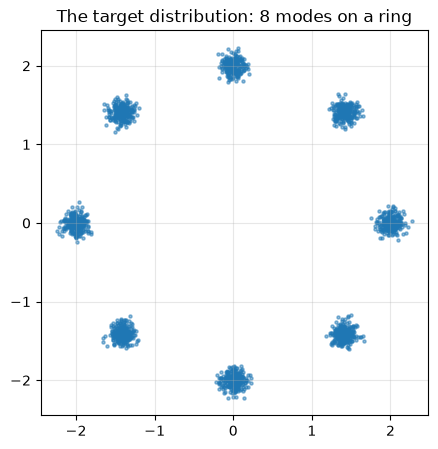

In [2]:
def sample_ring(n, modes=8, radius=2.0, spread=0.08):
    """Eight Gaussian blobs arranged on a circle: the classic GAN diagnostic."""
    angles = 2 * np.pi * rng.integers(0, modes, size=n) / modes
    centers = np.stack([radius * np.cos(angles), radius * np.sin(angles)], axis=1)
    return (centers + spread * rng.normal(size=(n, 2))).astype("float32")


real_ring = sample_ring(2000)
plt.figure(figsize=(5, 5))
plt.scatter(real_ring[:, 0], real_ring[:, 1], s=5, alpha=0.5)
plt.title("The target distribution: 8 modes on a ring")
plt.axis("equal"); plt.grid(True, alpha=0.3)
plt.show()

💻 **The code.** Two tiny MLPs, two optimizers, and the training step that is
the heart of every GAN ever written. Read the `train_step` slowly, because
everything in Module II is this function with convolutions swapped in.

Three details worth pausing on:

- **Two separate `GradientTape`s.** The discriminator's gradients must not
  touch the generator's weights and vice versa. We compute them separately and
  apply each to its own variable list. This is the "updating both networks
  independently" step.
- **`from_logits=True`.** Our discriminator outputs an unbounded score, not a
  probability. Letting the loss apply the sigmoid internally is numerically
  stabler than doing it in the model.
- **The labels.** Real → 1, fake → 0 for the discriminator. But when training
  the generator we feed its fakes in labelled **1**, meaning "pretend these are
  real", which is exactly the non-saturating loss written as a cross-entropy.


In [3]:
NOISE_DIM_2D = 2

def mlp(out_dim, name):
    return keras.Sequential([keras.Input(shape=(2,)),
                             layers.Dense(64, activation="relu"),
                             layers.Dense(64, activation="relu"),
                             layers.Dense(out_dim)], name=name)


toy_gen = mlp(2, "toy_generator")        # noise (2,) -> point (2,)
toy_disc = mlp(1, "toy_discriminator")   # point (2,) -> realness score (logit)

bce = keras.losses.BinaryCrossentropy(from_logits=True)
toy_g_opt = keras.optimizers.Adam(1e-3, beta_1=0.5)
toy_d_opt = keras.optimizers.Adam(1e-3, beta_1=0.5)


@tf.function
def toy_train_step(real_points):
    batch = tf.shape(real_points)[0]
    noise = tf.random.normal((batch, NOISE_DIM_2D))

    # --- 1. train the discriminator: real -> 1, fake -> 0 -------------------
    with tf.GradientTape() as d_tape:
        fake_points = toy_gen(noise, training=True)
        d_real = toy_disc(real_points, training=True)
        d_fake = toy_disc(fake_points, training=True)
        d_loss = bce(tf.ones_like(d_real), d_real) + bce(tf.zeros_like(d_fake), d_fake)
    d_grads = d_tape.gradient(d_loss, toy_disc.trainable_variables)
    toy_d_opt.apply_gradients(zip(d_grads, toy_disc.trainable_variables))

    # --- 2. train the generator: make the discriminator say "real" ----------
    with tf.GradientTape() as g_tape:
        fake_points = toy_gen(noise, training=True)
        d_fake = toy_disc(fake_points, training=True)      # gradient flows THROUGH the critic
        g_loss = bce(tf.ones_like(d_fake), d_fake)         # note the label: 1, not 0
    g_grads = g_tape.gradient(g_loss, toy_gen.trainable_variables)
    toy_g_opt.apply_gradients(zip(g_grads, toy_gen.trainable_variables))

    return d_loss, g_loss


TOY_STEPS = 3000                                      # <- knob
snapshots, snap_at = {}, [0, 200, 1000, TOY_STEPS]

for step in range(TOY_STEPS + 1):
    if step in snap_at:
        z = tf.random.normal((1500, NOISE_DIM_2D))
        snapshots[step] = toy_gen(z, training=False).numpy()
    d_l, g_l = toy_train_step(sample_ring(256))
    if step % 500 == 0:
        print(f"step {step:>5}  d_loss {float(d_l):.3f}  g_loss {float(g_l):.3f}")

W0000 00:00:1787192392.565822   30567 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


I0000 00:00:1787192392.666472   30567 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 29127 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5090, pci bus id: 0000:01:00.0, compute capability: 12.0a


step     0  d_loss 1.244  g_loss 0.672


step   500  d_loss 1.297  g_loss 0.744


step  1000  d_loss 1.213  g_loss 0.871


step  1500  d_loss 1.273  g_loss 0.798


step  2000  d_loss 1.354  g_loss 0.739


step  2500  d_loss 1.357  g_loss 0.817


step  3000  d_loss 1.381  g_loss 0.727


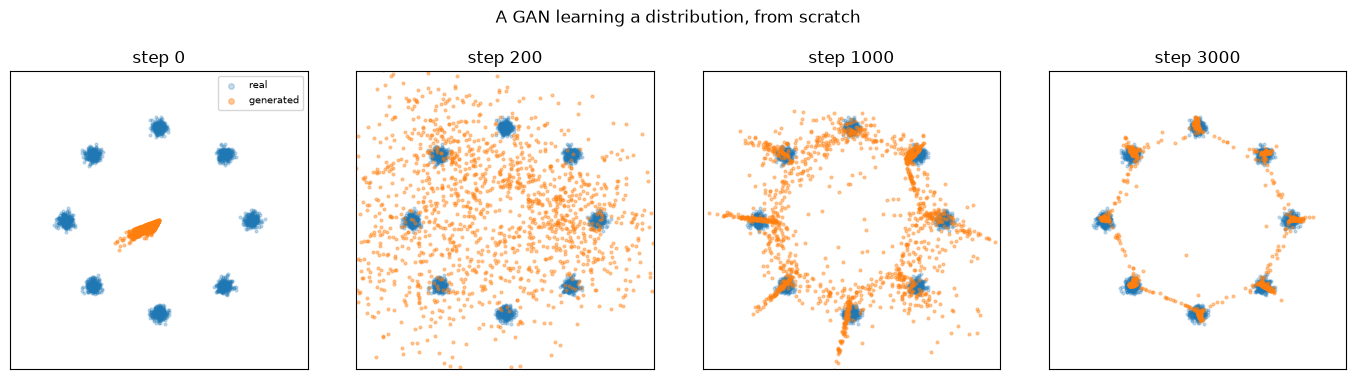

In [4]:
fig, axes = plt.subplots(1, len(snap_at), figsize=(14, 3.6))
for ax, step in zip(axes, snap_at):
    ax.scatter(real_ring[:, 0], real_ring[:, 1], s=4, alpha=0.25, label="real")
    ax.scatter(snapshots[step][:, 0], snapshots[step][:, 1], s=4, alpha=0.4,
               color="tab:orange", label="generated")
    ax.set_title(f"step {step}")
    ax.set_xlim(-3.2, 3.2); ax.set_ylim(-3.2, 3.2); ax.set_aspect("equal")
    ax.set_xticks([]); ax.set_yticks([])
axes[0].legend(loc="upper right", fontsize=7, markerscale=2)
fig.suptitle("A GAN learning a distribution, from scratch", y=1.04)
plt.tight_layout()
plt.show()

At step 0 the generator emits a blob near the origin, which is untrained noise
pushed through untrained weights. Within a couple hundred steps it has found the
ring. By the end it is sitting on the modes.

**Count the modes it covers.** If the orange cloud has taken up residence on
only three or four of the eight blobs, you have just watched **mode collapse**,
the GAN's signature failure. This cell is not rigged, so which one you get
depends on your seed and how far you train. The mechanism is worth
understanding, because nothing in the loss prevents it:

> The generator is rewarded for producing output the critic calls real. It is
> *never* rewarded for **variety**. Producing one perfect garment, over and
> over, is a completely valid solution to the objective as written.

What holds collapse at bay is only that the discriminator eventually notices
"everything I see is this same point" and starts rejecting it, pushing the
generator elsewhere. That can turn into an endless chase around the ring rather
than convergence. Watch for it in the metrics below.


---
# Module II — DCGAN: The Convolutional Version

The 2-D toy used dense layers because its data was two numbers. Images are a
spatial grid, so both networks become convolutional. This is the **DCGAN**
recipe (Radford et al., 2015), which turned GANs from a curiosity into
something that reliably produces images, mostly by pinning down a set of
architectural rules that stop training from exploding.

Everything in this module is a network you have already built, rewired. The
generator is Chapter 5's decoder; the discriminator is Chapter 2's classifier.
Only the loss is new, and you wrote that in Module I.

## II.a Data, and why the range changes to [-1, 1]

🧠 **The intuition.** In Chapter 5 we used a `sigmoid` output and images in
$[0, 1]$. GAN generators use `tanh` and images in $[-1, 1]$ instead. The reason
is about gradients: `tanh` is symmetric around zero and steeper near it, so a
freshly-initialised generator (whose pre-activations sit around zero) starts in
the responsive part of the curve rather than crushed against a floor. It is a
small thing that measurably stabilises early training, and the rule is simply
that **the data must be scaled to match the generator's output range**, or the
discriminator can separate real from fake on brightness alone.


In [5]:
fashion = load_dataset("zalando-datasets/fashion_mnist")
class_names = fashion["train"].features["label"].names


def split_to_arrays(split, n=None, image_col="image", label_col="label", seed=42):
    """Shuffle a HF split, optionally take the first n rows, return (images, labels)."""
    ds = split.shuffle(seed=seed)
    if n is not None:
        ds = ds.select(range(n))
    return np.stack([np.array(im) for im in ds[image_col]]), np.array(ds[label_col])


N_TRAIN = None                                          # <- knob: None = all 60k; try 20_000 to go faster
X_raw, y_train = split_to_arrays(fashion["train"], n=N_TRAIN)

X = (X_raw.astype("float32") / 127.5 - 1.0)[..., None]  # [0, 255] -> [-1, 1]
print("train:", X.shape, "| range:", X.min(), "to", X.max())

BATCH = 128
dataset = (tf.data.Dataset.from_tensor_slices(X)
           .shuffle(len(X), seed=42)
           .batch(BATCH, drop_remainder=True)
           .prefetch(tf.data.AUTOTUNE))
print(f"{len(X) // BATCH} batches per epoch")

train: (60000, 28, 28, 1) | range: -1.0 to 1.0


468 batches per epoch


## II.b The generator: noise in, image out

🧠 **The intuition.** The generator is the *decoder* from Chapter 5, cut loose
from its encoder. Same job, expanding a short vector into a picture, but where
the autoencoder's decoder received a code describing a specific garment, this
one receives pure random numbers. The 100 noise dimensions *become* the latent
space: the network is free to decide what each direction means, and it will
assign them meanings during training because that is the only way to cover the
variety in the data.

📐 **The math.** $G_\theta : \mathbb{R}^{100} \to [-1, 1]^{28 \times 28}$,
defining an implicit distribution $p_g$ as the pushforward of
$\mathcal{N}(0, I)$ through $G_\theta$. Note what is *absent*: there is no
density formula, no likelihood, no encoder. You cannot ask a GAN "how probable
is this image", you can only draw from it. That is the trade the GAN makes,
and it is why GANs sample beautifully but cannot score.

💻 **The code.** The DCGAN rules, all visible below:

1. Project the noise to a small spatial grid (7×7) with many channels, then
   upsample, never a giant dense layer straight to pixels.
2. `Conv2DTranspose` with stride 2 for each doubling: 7 → 14 → 28. Kernel 4
   with stride 2 divides evenly, which suppresses the checkerboard artefacts
   we warned about in Chapter 5, Module II.2.
3. `BatchNormalization` after each layer but **not** on the output.
4. `LeakyReLU` everywhere inside, `tanh` at the end.
5. `use_bias=False` wherever BatchNorm follows, since BN's own shift parameter
   makes the bias redundant.


In [6]:
NOISE_DIM = 100                                        # <- knob


def build_generator():
    z = keras.Input(shape=(NOISE_DIM,))

    x = layers.Dense(7 * 7 * 256, use_bias=False)(z)          # project...
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Reshape((7, 7, 256))(x)                        # ...and reshape to a grid

    x = layers.Conv2DTranspose(128, 4, strides=2, padding="same", use_bias=False)(x)  # 14x14
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Conv2DTranspose(64, 4, strides=2, padding="same", use_bias=False)(x)   # 28x28
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    out = layers.Conv2D(1, 5, padding="same", activation="tanh")(x)     # 28x28x1 in [-1, 1]
    return keras.Model(z, out, name="generator")


generator = build_generator()
generator.summary()

Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 12544)          │     1,254,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 12544)          │        50,176 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 128)    │       524,288 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 64)     │       131,072 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 1)      │         1,601 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,962,305 (7.49 MB)

 Trainable params: 1,936,833 (7.39 MB)

 Non-trainable params: 25,472 (99.50 KB)

I0000 00:00:1787192410.678359   30567 cuda_dnn.cc:461] Loaded cuDNN version 91900


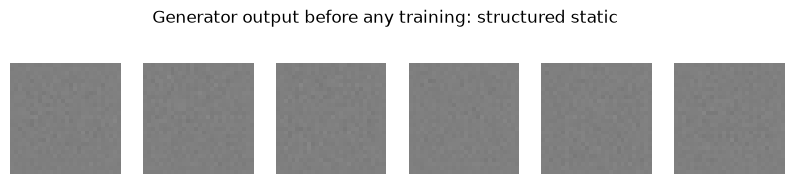

In [7]:
# What does an untrained generator produce? Worth seeing once, for the contrast.
noise_demo = tf.random.normal((6, NOISE_DIM))
untrained = generator(noise_demo, training=False).numpy()

fig, axes = plt.subplots(1, 6, figsize=(10, 1.8))
for ax, img in zip(axes, untrained):
    ax.imshow(img.squeeze(), cmap="gray", vmin=-1, vmax=1); ax.axis("off")
fig.suptitle("Generator output before any training: structured static", y=1.1)
plt.show()

## II.c The discriminator: an image classifier with two classes

🧠 **The intuition.** This is the most familiar network in the notebook, a
small CNN doing binary classification, "real or fake". The only unusual thing
about it is its purpose: we don't care about its accuracy as a product. It is a
*learned loss function*. Every time it discovers a new tell (blurry edges,
implausible sleeve lengths, checkerboard texture), that discovery becomes a
gradient signal pushing the generator to fix exactly that flaw.

📐 **The math.** $D_\psi : \mathbb{R}^{28\times28} \to \mathbb{R}$, emitting a
logit; $\sigma(D_\psi(x))$ is its estimated probability that $x$ is real.

💻 **The code.** More DCGAN rules:

- **Stride-2 convolutions, no pooling.** The discriminator learns its own
  downsampling. (This is the modern replacement for the `MaxPooling2D` in
  Chapter 5's encoder, as promised there.)
- **`LeakyReLU`, not `ReLU`.** A plain ReLU outputs exactly zero for all
  negative inputs, and a dead unit passes *no gradient back to the generator*.
  The 0.2 leak keeps the channel open. This matters far more in a GAN than in a
  classifier, because the generator's only teacher is the gradient through this
  network.
- **`Dropout`.** Deliberately handicaps the discriminator. A critic that wins
  too decisively drives $D(G(z)) \to 0$, where the generator's gradients
  vanish. Keeping the game close keeps it learning.


In [8]:
def build_discriminator():
    img = keras.Input(shape=(28, 28, 1))

    x = layers.Conv2D(64, 4, strides=2, padding="same")(img)   # 14x14
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv2D(128, 4, strides=2, padding="same")(x)    #  7x7
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Flatten()(x)
    logit = layers.Dense(1)(x)                                 # raw score, no sigmoid
    return keras.Model(img, logit, name="discriminator")


discriminator = build_discriminator()
discriminator.summary()

Model: "discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,561 (541.25 KB)

 Trainable params: 138,561 (541.25 KB)

 Non-trainable params: 0 (0.00 B)

## II.d The two losses, written out

🧠 **The intuition.** Both players are graded by the same referee: the
discriminator's verdict. The discriminator's loss asks how often it gets
fooled, trusting a fake or doubting a real, and the generator's loss asks the
same question from the opposite side, scoring well exactly when the fooling
works. One judgement, read from both ends of the table.

📐 **The math.** Both are binary cross-entropy on the discriminator's logits.
For a batch of real images $x$ and noise $z$:

$$ \mathcal{L}_D = \underbrace{-\mathbb{E}\big[\log \sigma(D(x))\big]}_{\text{call real images real}} \;\underbrace{-\; \mathbb{E}\big[\log\big(1 - \sigma(D(G(z)))\big)\big]}_{\text{call fakes fake}} $$

$$ \mathcal{L}_G = -\mathbb{E}\big[\log \sigma(D(G(z)))\big] \qquad \text{(non-saturating: "be called real")} $$

Notice that $\mathcal{L}_G$ is the *same expression* as the second half of
$\mathcal{L}_D$ with the label flipped from 0 to 1. That single flipped label
is the entire adversarial relationship, in code.

🧠 **What this means for "convergence".** There is no single loss going down.
Each network's loss depends on the other's current skill, so both curves wander,
and a generator loss that plummets usually means the *discriminator* is
failing, not that the images got good. GAN losses tell you about the balance of
the game, not about sample quality. We will therefore also track the
discriminator's accuracy on each side, which is far more readable.

## II.e One training step

💻 **The code.** Structurally identical to `toy_train_step`; only the networks
changed. We add two extras: **one-sided label smoothing** (train the
discriminator toward 0.9 rather than 1.0 for real images, which discourages
over-confident critics and is a standard stabiliser), and accuracy tracking.


In [9]:
bce = keras.losses.BinaryCrossentropy(from_logits=True)
g_opt = keras.optimizers.Adam(2e-4, beta_1=0.5)        # DCGAN's canonical settings:
d_opt = keras.optimizers.Adam(2e-4, beta_1=0.5)        # lr 2e-4, beta_1 lowered from 0.9

REAL_LABEL = 0.9                                       # <- knob: 1.0 disables label smoothing


@tf.function
def train_step(real_images):
    batch = tf.shape(real_images)[0]
    noise = tf.random.normal((batch, NOISE_DIM))

    # --- discriminator ------------------------------------------------------
    with tf.GradientTape() as d_tape:
        fake_images = generator(noise, training=True)
        d_real = discriminator(real_images, training=True)
        d_fake = discriminator(fake_images, training=True)
        d_loss = (bce(tf.fill(tf.shape(d_real), REAL_LABEL), d_real)
                  + bce(tf.zeros_like(d_fake), d_fake))
    d_grads = d_tape.gradient(d_loss, discriminator.trainable_variables)
    d_opt.apply_gradients(zip(d_grads, discriminator.trainable_variables))

    # --- generator ----------------------------------------------------------
    with tf.GradientTape() as g_tape:
        fake_images = generator(noise, training=True)
        d_fake_for_g = discriminator(fake_images, training=True)
        g_loss = bce(tf.ones_like(d_fake_for_g), d_fake_for_g)     # "call these real"
    g_grads = g_tape.gradient(g_loss, generator.trainable_variables)
    g_opt.apply_gradients(zip(g_grads, generator.trainable_variables))

    # --- diagnostics: how convinced is the critic, on each side? ------------
    # We report the critic's mean σ(logit), its "probability this is real",
    # rather than a thresholded accuracy, which the label smoothing above would
    # distort. Re-scored with training=False so dropout doesn't skew it.
    p_real = tf.reduce_mean(tf.sigmoid(discriminator(real_images, training=False)))
    p_fake = tf.reduce_mean(tf.sigmoid(discriminator(fake_images, training=False)))
    return d_loss, g_loss, p_real, p_fake

## II.f Train, watching the samples evolve

We hold a **fixed** set of 16 noise vectors aside and decode them at the end of
selected epochs. Because the input never changes, any change you see across the
grids is change in the *generator*, and this is the standard way to watch a GAN
learn, far more informative than the loss curves.


In [10]:
EPOCHS = 50                                            # <- knob: 15 is enough to see shapes
SNAPSHOT_EPOCHS = {1, 5, 10, 25, EPOCHS}

fixed_noise = tf.random.normal((16, NOISE_DIM), seed=7)
gallery, hist = {}, {"d_loss": [], "g_loss": [], "p_real": [], "p_fake": []}

for epoch in range(1, EPOCHS + 1):
    totals = None
    for n_batches, batch_images in enumerate(dataset, start=1):
        metrics = train_step(batch_images)
        # keep the running total on-device; pulling floats every batch stalls the GPU
        totals = list(metrics) if totals is None else [a + b for a, b in zip(totals, metrics)]
    for key, total in zip(hist, totals):
        hist[key].append(float(total) / n_batches)

    if epoch in SNAPSHOT_EPOCHS:
        gallery[epoch] = generator(fixed_noise, training=False).numpy()
    if epoch % 5 == 0 or epoch == 1:
        print(f"epoch {epoch:>3}  d_loss {hist['d_loss'][-1]:.3f}  g_loss {hist['g_loss'][-1]:.3f}"
              f"  | critic P(real) = {hist['p_real'][-1]:.2f} on real, {hist['p_fake'][-1]:.2f} on fake")

E0000 00:00:1787192411.972427   30567 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape indiscriminator_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


epoch   1  d_loss 1.377  g_loss 0.803  | critic P(real) = 0.47 on real, 0.45 on fake


epoch   5  d_loss 1.355  g_loss 0.836  | critic P(real) = 0.45 on real, 0.42 on fake


epoch  10  d_loss 1.358  g_loss 0.839  | critic P(real) = 0.45 on real, 0.42 on fake


epoch  15  d_loss 1.361  g_loss 0.831  | critic P(real) = 0.45 on real, 0.43 on fake


...

epoch  30  d_loss 1.363  g_loss 0.829  | critic P(real) = 0.45 on real, 0.43 on fake


epoch  35  d_loss 1.365  g_loss 0.832  | critic P(real) = 0.45 on real, 0.43 on fake


epoch  40  d_loss 1.364  g_loss 0.828  | critic P(real) = 0.45 on real, 0.43 on fake


epoch  45  d_loss 1.364  g_loss 0.832  | critic P(real) = 0.45 on real, 0.43 on fake


epoch  50  d_loss 1.363  g_loss 0.831  | critic P(real) = 0.45 on real, 0.43 on fake


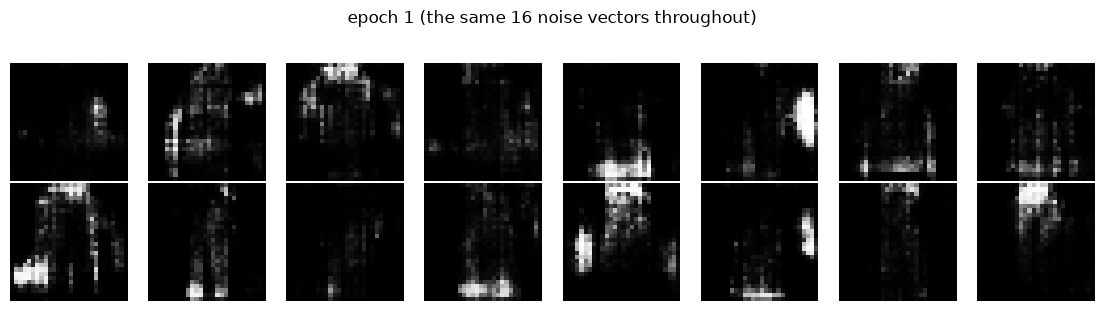

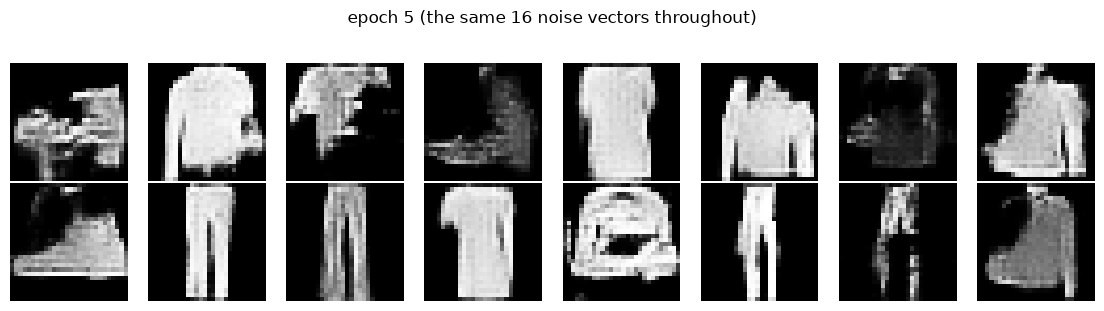

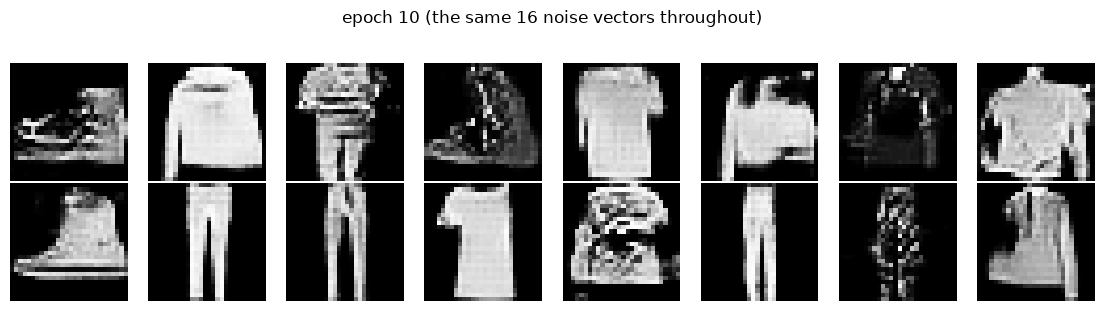

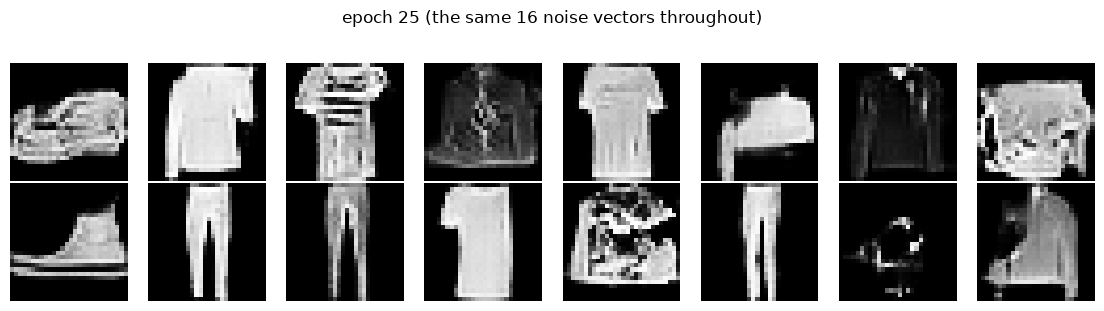

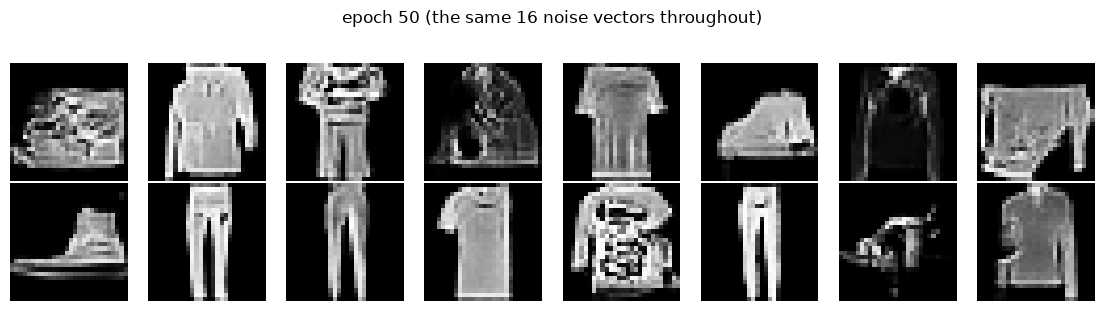

In [11]:
def show_grid(images, title, rows=2, cols=8):
    fig, axes = plt.subplots(rows, cols, figsize=(1.4 * cols, 1.5 * rows))
    for ax, img in zip(axes.flat, images):
        ax.imshow(img.squeeze(), cmap="gray", vmin=-1, vmax=1)
        ax.axis("off")
    fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()


for epoch in sorted(gallery):
    show_grid(gallery[epoch], f"epoch {epoch} (the same 16 noise vectors throughout)")

The progression is the lesson. Early epochs produce dark blobs with roughly the
right *statistics*, since the generator has learned that garments are bright
shapes on a black background, and nothing more. Silhouettes arrive next: the
outline of a boot, the two legs of a trouser. Texture and internal detail come
last, and note how **sharp** they are compared with Chapter 6's VAE samples.
Nobody asked for pixel-level accuracy; the discriminator simply learned that
blurry things are fake.

Because the noise is fixed, you can also follow *individual* tiles: position
(0, 0) stays "the same garment" across epochs while gradually resolving. That
consistency shows the generator's mapping from latent space to image space is
stabilising, not being rebuilt from scratch each epoch.


---
# Module III — Reading GAN Training

## III.a The curves, and how to read them

🧠 **The intuition.** Everything you learned about training curves from
supervised learning is wrong here. There is no validation loss to watch, no
"converged" state to reach, and a smoothly-descending generator loss is a
**bad** sign, because it means the discriminator has stopped putting up a
fight. What you actually want is a stalemate that never resolves.

The readable diagnostic is the right-hand plot: the critic's average
$\sigma(\text{logit})$, its "how likely do I think this is real", computed
separately on real and on generated images. The healthy pattern:

- The two traces **separate but stay close**, and both drift toward the middle.
  The critic can still tell, but not confidently.
- Both losses wander in a band; neither collapses to zero.
- If the fake trace pins to 0 and `g_loss` climbs without bound, the critic has
  won outright and the generator's gradients have dried up.
- If the two traces **meet at 0.5** *and* the samples look like noise, the
  critic has given up rather than the generator having succeeded, so always
  check the images before celebrating.

⚠️ Note the effect of our label smoothing: the critic is trained toward 0.9 for
real rather than 1.0, so a genuinely-uncertain critic settles a little *below*
0.5, not exactly on it. Read the **gap** between the traces, not their absolute
height. (This is also why we plot probabilities rather than a thresholded
accuracy: a fixed 0.5 threshold would make a perfectly healthy critic look
broken.)

💻 **The code.** Both panels come from the run you just trained: the two
losses on the left, the critic's per-side probabilities on the right, with the
shaded band marking the gap. Do not look for a steady descent. Look for two
curves circling each other, and a gap that narrows without ever closing.


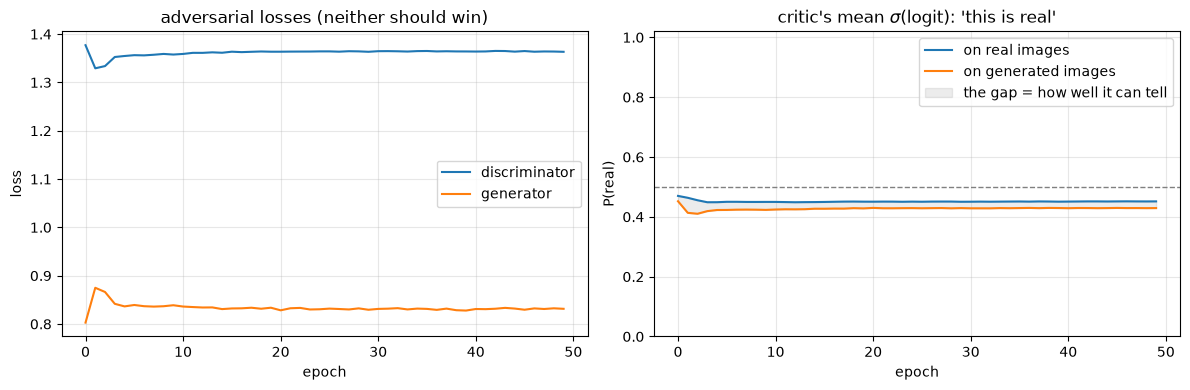

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(hist["d_loss"], label="discriminator")
axes[0].plot(hist["g_loss"], label="generator")
axes[0].set_title("adversarial losses (neither should win)")
axes[0].set_ylabel("loss")

axes[1].plot(hist["p_real"], label="on real images")
axes[1].plot(hist["p_fake"], label="on generated images")
axes[1].axhline(0.5, color="gray", linestyle="--", linewidth=1)
axes[1].set_title("critic's mean $\\sigma$(logit): 'this is real'")
axes[1].set_ylim(0, 1.02); axes[1].set_ylabel("P(real)")
axes[1].fill_between(range(len(hist["p_real"])), hist["p_fake"], hist["p_real"],
                     alpha=0.15, color="gray", label="the gap = how well it can tell")

for ax in axes:
    ax.set_xlabel("epoch"); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## III.b The latent space, again

🧠 **The intuition.** Chapter 5 built a latent space by *compressing* real
images into it. The GAN never did that. It was handed a blank 100-dimensional
Gaussian and told to make it useful. Did an organised space emerge anyway? The
same test applies: walk in a straight line between two noise vectors and decode
every step. If the intermediate frames are plausible garments rather than
cross-fades, the generator has learned a genuinely continuous mapping.

📐 **A subtlety worth knowing.** Linear interpolation between two Gaussian
samples passes closer to the origin than typical draws do: in 100 dimensions
almost all the probability mass sits in a thin shell at radius $\approx\sqrt{d}$,
and the midpoint of a chord is well inside it. So the midpoints are, strictly,
slightly off-distribution. **Spherical** interpolation (`slerp`) travels along
the shell instead and gives cleaner walks; we use it here, with the linear
version alongside so you can see the difference for yourself.

💻 **The code.** The next cell decodes the same two endpoints along both
paths, linear on top and spherical below. Watch the middle frames: every step
should be a plausible garment, and the linear row's midpoints tend to come out
slightly dimmer and mushier than the spherical row's.


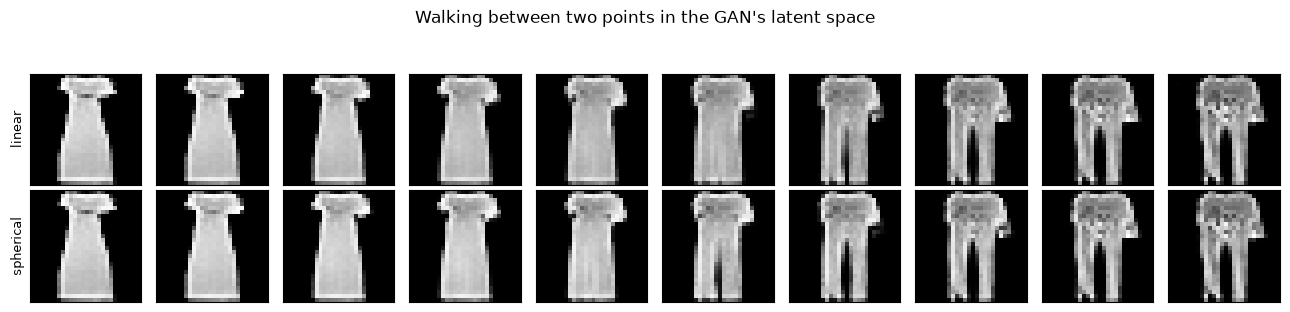

In [13]:
def lerp(z1, z2, steps):
    a = np.linspace(0, 1, steps)[:, None]
    return (1 - a) * z1 + a * z2


def slerp(z1, z2, steps):
    """Interpolate along the great circle between two vectors (constant radius)."""
    a = np.linspace(0, 1, steps)[:, None]
    unit1, unit2 = z1 / np.linalg.norm(z1), z2 / np.linalg.norm(z2)
    omega = np.arccos(np.clip(unit1 @ unit2, -1, 1))
    return (np.sin((1 - a) * omega) * z1 + np.sin(a * omega) * z2) / np.sin(omega)


z_a, z_b = rng.normal(size=(2, NOISE_DIM)).astype("float32")

fig, axes = plt.subplots(2, 10, figsize=(13, 3))
for row, (path, tag) in enumerate([(lerp(z_a, z_b, 10), "linear"),
                                   (slerp(z_a, z_b, 10), "spherical")]):
    walk = generator(path.astype("float32"), training=False).numpy()
    for ax, img in zip(axes[row], walk):
        ax.imshow(img.squeeze(), cmap="gray", vmin=-1, vmax=1)
        ax.set_xticks([]); ax.set_yticks([])
    axes[row, 0].set_ylabel(tag, fontsize=9)
fig.suptitle("Walking between two points in the GAN's latent space", y=1.04)
plt.tight_layout()
plt.show()

## III.c Measuring mode collapse instead of guessing at it

🧠 **The intuition.** Module I showed mode collapse on a ring, where you could
simply count the blobs. On images you cannot eyeball it, since a grid of 16
samples might miss a whole missing class. So we measure it: train an ordinary
Fashion-MNIST classifier on the *real* data, then use it to label a large batch
of generated samples. If the generator covers the data distribution, the ten
classes should come out roughly evenly. Whatever is missing, it has collapsed
away from.

📐 **What this is (and isn't).** This is a crude relative of the **Inception
Score** and of the classifier-based coverage metrics used in the literature.
It measures *diversity across classes* only, and says nothing about quality, or
about diversity *within* a class. A generator producing one perfect sneaker and
one perfect bag would score fine on nine-tenths of this test and still be badly
collapsed. Use it as a smoke detector, not a certificate.

💻 **The code.** The next two cells build the smoke detector: a small CNN
trained on the real labeled images, then used to classify 4,000 generated
samples. The bar chart compares the generator's class shares against the real
data's; any class far below its dashed line is a mode the generator dropped.


In [14]:
clf = keras.Sequential([
    keras.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, 3, activation="relu"), layers.MaxPooling2D(2),
    layers.Conv2D(64, 3, activation="relu"), layers.MaxPooling2D(2),
    layers.Flatten(), layers.Dropout(0.3), layers.Dense(10, activation="softmax"),
], name="mode_probe")
clf.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

X_clf = (X_raw.astype("float32") / 255.0)[..., None]     # this probe wants [0, 1]
clf.fit(X_clf, y_train, epochs=5, batch_size=128, validation_split=0.1, verbose=2)

Epoch 1/5


I0000 00:00:1787192771.397400   30719 service.cc:153] XLA service 0x7c900406cbd0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1787192771.397439   30719 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5090, Compute Capability 12.0a (Driver: 13.3.0; Runtime: 12.8.0; Toolkit: 12.5.0; DNN: 9.19.0)
I0000 00:00:1787192771.408918   30719 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1787192771.496157   30719 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_228525__.30


I0000 00:00:1787192773.377265   30719 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


I0000 00:00:1787192774.289034   30719 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_228525__.30


422/422 - 6s - 14ms/step - accuracy: 0.7634 - loss: 0.6618 - val_accuracy: 0.8398 - val_loss: 0.4305


...

422/422 - 1s - 2ms/step - accuracy: 0.8634 - loss: 0.3833 - val_accuracy: 0.8695 - val_loss: 0.3552


Epoch 4/5


422/422 - 1s - 2ms/step - accuracy: 0.8742 - loss: 0.3521 - val_accuracy: 0.8825 - val_loss: 0.3232


Epoch 5/5


422/422 - 1s - 2ms/step - accuracy: 0.8791 - loss: 0.3347 - val_accuracy: 0.8847 - val_loss: 0.3105


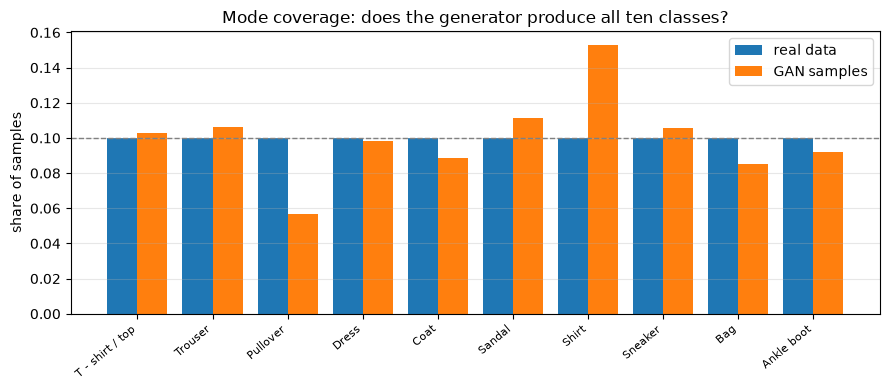

under-represented (<50% of expected): none, so coverage is good
over-represented  (>200% of expected): none


In [15]:
N_PROBE = 4000
samples = generator(tf.random.normal((N_PROBE, NOISE_DIM)), training=False).numpy()
sample_classes = clf.predict((samples + 1) / 2, verbose=0).argmax(axis=1)   # [-1,1] -> [0,1]

gen_counts = np.bincount(sample_classes, minlength=10) / N_PROBE
real_counts = np.bincount(y_train, minlength=10) / len(y_train)

fig, ax = plt.subplots(figsize=(9, 4))
pos = np.arange(10)
ax.bar(pos - 0.2, real_counts, 0.4, label="real data")
ax.bar(pos + 0.2, gen_counts, 0.4, label="GAN samples")
ax.axhline(0.1, color="gray", linestyle="--", linewidth=1)
ax.set_xticks(pos); ax.set_xticklabels(class_names, rotation=40, ha="right", fontsize=8)
ax.set_ylabel("share of samples"); ax.legend(); ax.grid(True, axis="y", alpha=0.3)
ax.set_title("Mode coverage: does the generator produce all ten classes?")
plt.tight_layout()
plt.show()

missing = [class_names[i] for i in range(10) if gen_counts[i] < 0.5 * real_counts[i]]
overrep = [class_names[i] for i in range(10) if gen_counts[i] > 2.0 * real_counts[i]]
print("under-represented (<50% of expected):", missing or "none, so coverage is good")
print("over-represented  (>200% of expected):", overrep or "none")

Some skew is normal, and the visually-similar classes (shirt / coat / pullover)
trade share with each other partly because the *probe classifier* confuses them
too. A class near zero is the real warning sign.

**If you want to see collapse deliberately:** re-run Module II with
`d_opt = Adam(2e-3)`. A discriminator that learns ten times faster overwhelms
the generator, and the generator's safest response is to retreat to whatever
narrow region still fools it.

## III.d What the field did about all this

You have now met the two structural problems the GAN literature spent years on:

| Problem | What it looks like | The standard fixes |
|---|---|---|
| **Mode collapse** | Generator covers a fraction of the data | Minibatch discrimination (let the critic see a *batch*, so "all identical" is itself a tell), unrolled GANs, **WGAN-GP** |
| **Unstable / vanishing gradients** | One network overwhelms the other, samples freeze or blow up | Label smoothing (used above), **spectral normalisation** on the critic, two-timescale learning rates, gradient penalty |

**WGAN-GP** is the single most important entry there: it replaces the
Jensen–Shannon divergence with the **Wasserstein** (earth-mover) distance,
which, unlike JS, still provides a useful gradient when the two distributions
barely overlap. That is precisely the situation at the start of training, and
precisely when the original formulation is weakest.

GANs dominated image generation from 2015 to roughly 2021, and StyleGAN's faces
are still among the sharpest images any model produces. What displaced them for
general-purpose generation was **trainability**, not better samples.


---
# Wrap-Up

| You built | The transferable lesson |
|---|---|
| 2-D toy GAN on a ring | The whole algorithm fits in one `train_step` with two tapes; watch mode collapse happen live |
| DCGAN generator | Chapter 5's decoder, fed pure noise; project → reshape → stride-2 transpose convolutions → `tanh` |
| DCGAN discriminator | A learned loss function rather than a classifier; `LeakyReLU` and dropout keep it from winning too hard |
| Non-saturating loss | Flip the label from 0 to 1 to get steep gradients exactly when the generator is losing |
| Loss curves + mode probe | GAN losses measure *balance*, not quality; measure coverage separately |

**The trade you just made.** The GAN threw out the per-pixel loss and got
sharpness, so Chapter 5's blur is gone. In exchange it threw out every
guarantee: no likelihood, no encoder, no meaningful convergence criterion, and a
training procedure that can silently discard half your data distribution.

**Diffusion gets both.** Diffusion models go back to a plain MSE objective, the
very thing that caused the blur, but change *what is predicted*. Instead of
asking one network to produce a finished image in one shot (where hedging is
the safe play), they ask it to remove a *little* noise from an almost-clean
image, hundreds of times in sequence. Each individual prediction is so
constrained that there is nothing to hedge about, so MSE stops causing blur.

The payoff is a model with GAN-level sharpness, VAE-level coverage of the data
(no mode collapse, since the objective explicitly covers every noise level of
every training image), and a training loop as boring and stable as a supervised
classifier's. And the network doing the denoising is the encoder-decoder you
built in Chapter 5, with the skip connections you built in Chapter 3: a U-Net.

The cell below is the chapter's closing argument: sixteen garments that do
not exist, sampled from noise by the generator you just trained.


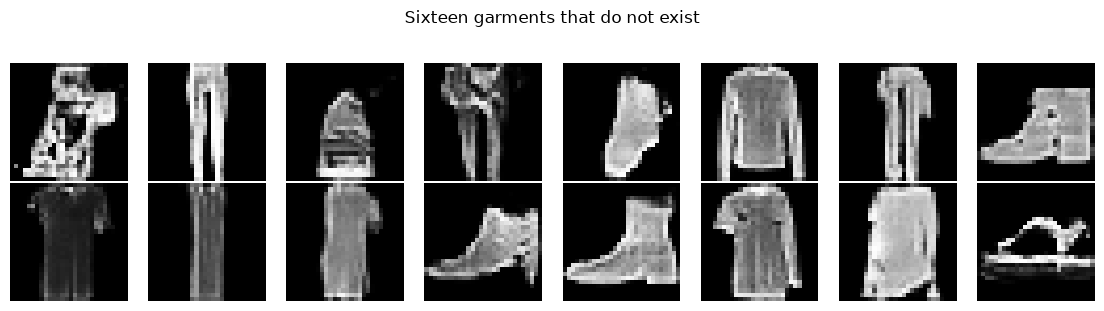

In [16]:
show_grid(generator(tf.random.normal((16, NOISE_DIM)), training=False).numpy(),
          "Sixteen garments that do not exist", rows=2, cols=8)